In [46]:
import pandas as pd
df = pd.read_csv("./Position_Salaries.csv")
df.describe()

,Level,Salary,Years of Experience
count,48.000,4.800000e+01,48.000000
mean,12.250,1.425490e+07,29.791667
std,7.000,2.627770e+07,7.992572
min,0.500,3.000000e+04,2.900000
25%,6.375,1.687500e+05,31.150000
50%,12.250,2.400000e+06,32.900000
75%,18.125,1.450000e+07,34.300000
max,24.000,1.200000e+08,35.000000


In [11]:
X = df.loc[:, ["Level", "Years of Experience"]]
y = df["Salary"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, test_size=0.2)

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=0, n_estimators=100)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred

array([2.0765e+06, 2.9655e+05, 3.6290e+07, 5.3350e+05, 1.3860e+07,
       5.2900e+07, 7.3350e+07, 2.5900e+05, 3.8100e+05, 3.9650e+04])

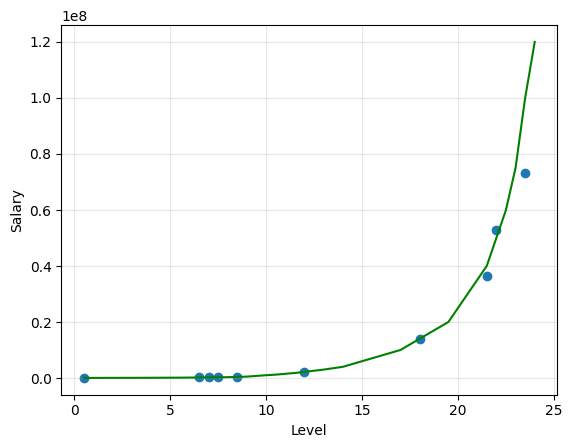

In [37]:
import matplotlib.pyplot as plt

plt.plot(X["Level"], y, color="green")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.scatter(X_test["Level"], y_pred)
plt.grid(True, alpha=0.3)

In [38]:
residuals = y_test - y_pred
residuals

23      123500.0
12     -121550.0
42     3710000.0
16     -158500.0
35      140000.0
43    -2900000.0
46    26650000.0
13      -59000.0
14     -151000.0
0        -9650.0
Name: Salary, dtype: float64

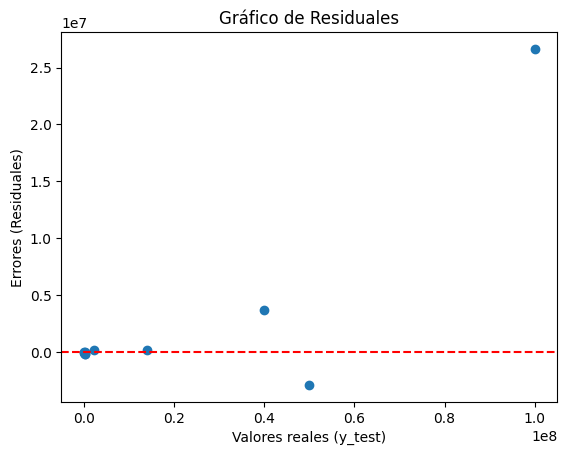

In [39]:
plt.scatter(y_test, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Errores (Residuales)")
plt.title("Gráfico de Residuales")
plt.show()

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')

r2 = r2_score(y_test, y_pred)
print(f'R^2: {r2:.4f}')

MAE: 3402320.00
MSE: 73249772402500.00
RMSE: 8558608.09
R^2: 0.9268


MSE: 73249772402500.00
RMSE: 8558608.09
